## <center>CITS5508 Lab sheet 7</center>

In [1]:
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
df = pd.read_csv('airline-safety.csv')

In [3]:
df.head()

,airline,avail_seat_km_per_week,incidents_85_99,fatal_accidents_85_99,fatalities_85_99,incidents_00_14,fatal_accidents_00_14,fatalities_00_14
0,Aer Lingus,320906734,2,0,0,0,0,0
1,Aeroflot*,1197672318,76,14,128,6,1,88
2,Aerolineas Argentinas,385803648,6,0,0,1,0,0
3,Aeromexico*,596871813,3,1,64,5,0,0
4,Air Canada,1865253802,2,0,0,2,0,0


In [4]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(df.iloc[:, 1:])

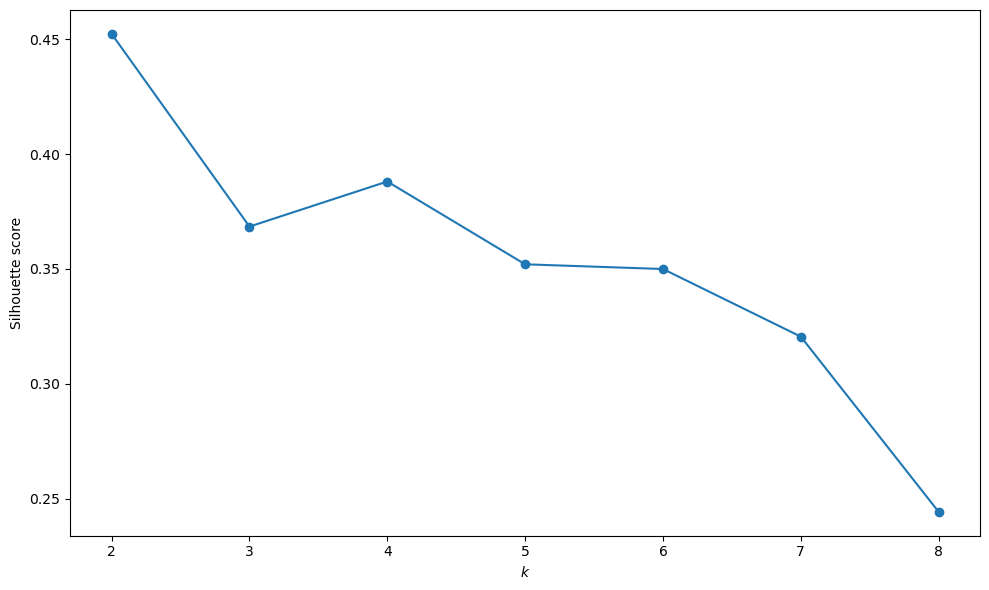

In [5]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

scores = []

for k in range(2, 9):
    kmeans = KMeans(n_clusters=k, random_state=5508)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(10, 6))
plt.plot(range(2, 9), scores, marker='o')
plt.xlabel(r'$k$')
plt.ylabel('Silhouette score')

plt.tight_layout()
plt.show()

In [6]:
def fit_kmeans(X):
    kmeans = KMeans(n_clusters=2, random_state=5508)
    labels = kmeans.fit_predict(X)

    df_clust = df.copy()
    df_clust['cluster'] = labels
    return df_clust

In [7]:
df_reg = fit_kmeans(X)
df_reg.groupby('cluster').describe().T

cluster                                  0             1
avail_seat_km_per_week count  4.300000e+01  1.300000e+01
                       mean   1.051860e+09  2.485295e+09
                       std    8.723109e+08  2.338516e+09
                       min    2.593733e+08  3.485631e+08
                       25%    4.154949e+08  8.132165e+08
                       50%    6.829719e+08  1.509196e+09
                       75%    1.638510e+09  3.004003e+09
                       max    3.426530e+09  7.139291e+09
incidents_85_99        count  4.300000e+01  1.300000e+01
                       mean   3.674419e+00  1.876923e+01
                       std    2.792174e+00  1.847590e+01
                       min    0.000000e+00  3.000000e+00
                       25%    2.000000e+00  8.000000e+00
                       50%    3.000000e+00  1.400000e+01
                       75%    5.500000e+00  2.100000e+01
                       max    1.200000e+01  7.600000e+01
fatal_accidents_85_99  count  4.300000e+01  1.300000e+01
                       mean   1.116279e+00  5.692308e+00
                       std    1.294849e+00  3.772369e+00
                       min    0.000000e+00  1.000000e+00
                       25%    0.000000e+00  3.000000e+00
                       50%    1.000000e+00  5.000000e+00
                       75%    1.500000e+00  7.000000e+00
                       max    5.000000e+00  1.400000e+01
fatalities_85_99       count  4.300000e+01  1.300000e+01
                       mean   8.476744e+01  2.038462e+02
                       std    1.363133e+02  1.476329e+02
                       min    0.000000e+00  3.400000e+01
                       25%    0.000000e+00  9.800000e+01
                       50%    4.000000e+00  1.670000e+02
                       75%    1.150000e+02  2.600000e+02
                       max    5.200000e+02  5.350000e+02
incidents_00_14        count  4.300000e+01  1.300000e+01
                       mean   2.651163e+00  9.000000e+00
                       std    2.515511e+00  6.244998e+00
                       min    0.000000e+00  2.000000e+00
                       25%    1.000000e+00  5.000000e+00
                       50%    2.000000e+00  7.000000e+00
                       75%    4.000000e+00  1.100000e+01
                       max    1.100000e+01  2.400000e+01
fatal_accidents_00_14  count  4.300000e+01  1.300000e+01
                       mean   2.790698e-01  1.923077e+00
                       std    5.035863e-01  4.935481e-01
                       min    0.000000e+00  1.000000e+00
                       25%    0.000000e+00  2.000000e+00
                       50%    0.000000e+00  2.000000e+00
                       75%    5.000000e-01  2.000000e+00
                       max    2.000000e+00  3.000000e+00
fatalities_00_14       count  4.300000e+01  1.300000e+01
                       mean   2.072093e+01  1.706154e+02
                       std    5.649034e+01  1.641679e+02
                       min    0.000000e+00  2.200000e+01
                       25%    0.000000e+00  5.100000e+01
                       50%    0.000000e+00  9.200000e+01
                       75%    5.000000e-01  2.250000e+02
                       max    2.830000e+02  5.370000e+02

In [8]:
X_old = df[['incidents_85_99', 'fatal_accidents_85_99', 'fatalities_85_99']]
X_new = df[['incidents_00_14', 'fatal_accidents_00_14', 'fatalities_00_14']]

X_old = StandardScaler().fit_transform(X_old)
X_new = StandardScaler().fit_transform(X_new)

In [9]:
df_old = fit_kmeans(X_old)
df_old.groupby('cluster').describe().T

cluster                                  0             1
avail_seat_km_per_week count  4.000000e+01  1.600000e+01
                       mean   1.125833e+09  2.031591e+09
                       std    9.426345e+08  2.222066e+09
                       min    2.593733e+08  3.485631e+08
                       25%    4.167387e+08  5.994425e+08
                       50%    6.904922e+08  1.033463e+09
                       75%    1.847239e+09  1.914814e+09
                       max    3.426530e+09  7.139291e+09
incidents_85_99        count  4.000000e+01  1.600000e+01
                       mean   3.650000e+00  1.600000e+01
                       std    2.991869e+00  1.752332e+01
                       min    0.000000e+00  2.000000e+00
                       25%    1.750000e+00  7.750000e+00
                       50%    3.000000e+00  1.100000e+01
                       75%    5.250000e+00  1.950000e+01
                       max    1.400000e+01  7.600000e+01
fatal_accidents_85_99  count  4.000000e+01  1.600000e+01
                       mean   1.000000e+00  5.125000e+00
                       std    1.176697e+00  3.667424e+00
                       min    0.000000e+00  1.000000e+00
                       25%    0.000000e+00  3.000000e+00
                       50%    1.000000e+00  4.500000e+00
                       75%    1.000000e+00  6.250000e+00
                       max    4.000000e+00  1.400000e+01
fatalities_85_99       count  4.000000e+01  1.600000e+01
                       mean   3.550000e+01  3.046875e+02
                       std    5.641604e+01  1.241616e+02
                       min    0.000000e+00  1.010000e+02
                       25%    0.000000e+00  2.315000e+02
                       50%    3.000000e+00  3.105000e+02
                       75%    5.425000e+01  3.485000e+02
                       max    2.290000e+02  5.350000e+02
incidents_00_14        count  4.000000e+01  1.600000e+01
                       mean   2.900000e+00  7.187500e+00
                       std    2.436896e+00  6.804104e+00
                       min    0.000000e+00  0.000000e+00
                       25%    1.000000e+00  2.000000e+00
                       50%    2.000000e+00  4.500000e+00
                       75%    5.000000e+00  1.100000e+01
                       max    8.000000e+00  2.400000e+01
fatal_accidents_00_14  count  4.000000e+01  1.600000e+01
                       mean   4.250000e-01  1.250000e+00
                       std    7.120753e-01  9.309493e-01
                       min    0.000000e+00  0.000000e+00
                       25%    0.000000e+00  7.500000e-01
                       50%    0.000000e+00  1.000000e+00
                       75%    1.000000e+00  2.000000e+00
                       max    2.000000e+00  3.000000e+00
fatalities_00_14       count  4.000000e+01  1.600000e+01
                       mean   4.660000e+01  7.781250e+01
                       std    1.114940e+02  1.112907e+02
                       min    0.000000e+00  0.000000e+00
                       25%    0.000000e+00  7.500000e-01
                       50%    0.000000e+00  3.450000e+01
                       75%    4.000000e+00  9.625000e+01
                       max    5.370000e+02  4.160000e+02

In [10]:
df_new = fit_kmeans(X_new)
df_new.groupby('cluster').describe().T

cluster                                  0             1
avail_seat_km_per_week count  3.800000e+01  1.800000e+01
                       mean   1.108779e+09  1.966956e+09
                       std    9.078621e+08  2.150268e+09
                       min    2.593733e+08  2.774148e+08
                       25%    4.211027e+08  6.307605e+08
                       50%    6.747575e+08  1.002259e+09
                       75%    1.726593e+09  2.328290e+09
                       max    3.426530e+09  7.139291e+09
incidents_85_99        count  3.800000e+01  1.800000e+01
                       mean   3.763158e+00  1.438889e+01
                       std    2.898594e+00  1.716405e+01
                       min    0.000000e+00  1.000000e+00
                       25%    2.000000e+00  5.000000e+00
                       50%    3.000000e+00  9.000000e+00
                       75%    6.000000e+00  1.825000e+01
                       max    1.200000e+01  7.600000e+01
fatal_accidents_85_99  count  3.800000e+01  1.800000e+01
                       mean   1.236842e+00  4.166667e+00
                       std    1.324085e+00  4.062019e+00
                       min    0.000000e+00  0.000000e+00
                       25%    0.000000e+00  1.000000e+00
                       50%    1.000000e+00  3.000000e+00
                       75%    2.000000e+00  5.750000e+00
                       max    5.000000e+00  1.400000e+01
fatalities_85_99       count  3.800000e+01  1.800000e+01
                       mean   8.726316e+01  1.655000e+02
                       std    1.367368e+02  1.566101e+02
                       min    0.000000e+00  0.000000e+00
                       25%    0.000000e+00  4.150000e+01
                       50%    1.000000e+01  1.145000e+02
                       75%    1.315000e+02  2.535000e+02
                       max    5.200000e+02  5.350000e+02
incidents_00_14        count  3.800000e+01  1.800000e+01
                       mean   2.473684e+00  7.611111e+00
                       std    2.575738e+00  5.781704e+00
                       min    0.000000e+00  2.000000e+00
                       25%    1.000000e+00  4.000000e+00
                       50%    2.000000e+00  6.000000e+00
                       75%    4.000000e+00  9.500000e+00
                       max    1.100000e+01  2.400000e+01
fatal_accidents_00_14  count  3.800000e+01  1.800000e+01
                       mean   1.578947e-01  1.722222e+00
                       std    3.695370e-01  5.745131e-01
                       min    0.000000e+00  1.000000e+00
                       25%    0.000000e+00  1.000000e+00
                       50%    0.000000e+00  2.000000e+00
                       75%    0.000000e+00  2.000000e+00
                       max    1.000000e+00  3.000000e+00
fatalities_00_14       count  3.800000e+01  1.800000e+01
                       mean   2.868421e+00  1.666667e+02
                       std    1.358889e+01  1.429076e+02
                       min    0.000000e+00  2.200000e+01
                       25%    0.000000e+00  8.500000e+01
                       50%    0.000000e+00  1.095000e+02
                       75%    0.000000e+00  2.157500e+02
                       max    8.300000e+01  5.370000e+02

In [11]:
import numpy as np
eps = np.finfo(float).eps

df['incident_change'] = (df['incidents_00_14'] - df['incidents_85_99']) / (df['incidents_85_99'] + eps)
df['fatal_accident_change'] = (df['fatal_accidents_00_14'] - df['fatal_accidents_85_99']) / (df['fatal_accidents_85_99'] + eps)
df['fatalities_change'] = (df['fatalities_00_14'] - df['fatalities_85_99']) / (df['fatalities_85_99'] + eps)

In [12]:
X_feats = StandardScaler().fit_transform(df[['avail_seat_km_per_week', 'incident_change', 'fatal_accident_change', 'fatalities_change']])

In [13]:
df_feats = fit_kmeans(X_feats)
df_feats.groupby('cluster').describe().T

cluster                                  0             1
avail_seat_km_per_week count  5.100000e+01  5.000000e+00
                       mean   1.462775e+09  5.874576e+08
                       std    1.511685e+09  2.936621e+08
                       min    2.593733e+08  2.774148e+08
                       25%    4.912192e+08  3.013798e+08
...                                    ...           ...
fatalities_change      min   -1.000000e+00  3.152520e+16
                       25%   -1.000000e+00  3.963168e+17
                       50%   -8.746929e-01  4.953960e+17
                       75%    0.000000e+00  6.440147e+17
                       max    1.479412e+01  1.274519e+18

[80 rows x 2 columns]